In [1]:
import gmsh
from simsopt.configs import get_data
from simsopt.mhd import Vmec
import numpy as np
import jax
import time

# Loading the W7-X standard configuration 
# plasma surface. wout file comes from Landreman's
# VMEC equilibrium archive: 
# https://github.com/landreman/vmec_equilibria/blob/master/W7-X/Standard/
eq = Vmec('../fixed-continuation/wout.nc', keep_all_files=True)
# Adjusting resolution and taking a half-field-period
n_phi = 25
n_theta = 50
plasma_surface = type(eq.boundary)(
    nfp=eq.boundary.nfp, stellsym=eq.boundary.stellsym,
    mpol=eq.boundary.mpol, ntor=eq.boundary.ntor,
    quadpoints_phi=np.linspace(0, 1/2/eq.boundary.nfp, n_phi, endpoint=False),
    quadpoints_theta=np.linspace(0, 1, n_theta, endpoint=False),
)
plasma_surface.set_dofs(eq.boundary.get_dofs())

# Loading the W7-X coils.
coil_per_half_fp = 5
# The number of quadpoints here controls the mesh
# density in coil-fem. The meshing routine will
# try choose the cell number in the cross section 
# to make the aspect ratio close to one. Please see 
# the next sections for details. The resolution is
# low here to fit on a 8GB RTX 4060.  
curves, currents, axis, nfp, bs = get_data(
    'w7x', coil_order=10, points_per_period=4
)
base_curves = curves[:coil_per_half_fp]
base_currents = currents[:coil_per_half_fp]

## Defining `coil-fem` penalty

### FEM options and material properties

In [2]:
# Rectangular 100 mm × 50 mm cross-section (half-widths in metres).
# This single dict will be broadcast to all base coils automatically.
# The mesh density is controlled by the quadpoint number in base_curve.
mesh_options = {
    'shape'       : 'rect',  # Rectangular cross sections
    'w1'          : 0.2,     # 0.20 m full-width
    'w2'          : 0.2,     # 0.20 m full-width
    'frame'       : 'rmf',   # Cross sections oriented to a rotation-minimizing frame
    'aspect_ratio': 1.0,     # Aim for cubic elements
    'mesh_type'   : 'TET10', # Quadratic tetrahedral mesh and elements.
}

# Problem and solver options.
problem_options = {
    'winkler_k'      : 1e10,    # Winkler spring stiffness (N/m³)
    'solver'         : 'cudss', # A GPU direct sparse solver. Strongly 
    'adjoint_solver' : 'cudss', # recommended.
}

# Material options. Here, we assumes the coils are composed
# uniformly of 316LN stainless steel. Material properties cited 
# from DOI: 10.1016/j.nucengdes.2013.08.016
material_options = {
    'E'      : 205000000000, # Young's modulus (Pa)
    'nu'     : 0.3,          # Poisson's ratio (dimless)
    'density': 8000,         # Density (kg/m³)
    'itc'    : 0.0029,       # Integral thermal contraction (ΔL/L, dimless)
}

# Gravity options.
# This is a stellarator-symmetric case.
# For now gravity won't be correct.
gravity_options = {
    'g_vec': (0, 0, 0), # g vector in (x, y, z)   (m/s²)
}

### Support structures
Before beginning optimization, we first define a support structure for the
coilset. Support clamps in `coil-fem` are simsopt `Optimizables`. In this
example, we use `CoilSupportBeams`. In addition to fixed clamps, 
this optimizable supports two types of beams: 
1. Coil-coil beams that connects two adjacent coils
2. Coil-foundation beams that connects a coil to a fixed point in space.

In [3]:
beam_options = {
    'n_beam_cc': 4,     # 3 coil-coil beams
    'n_beam_cf': 0,     # No coil-foundation beams for simplicity
    'E': material_options['E'],  # 316LN's Young's modulus (Pa)
    'nu': material_options['nu'],          # 316LN's Poisson's ratio (dimless)
    'cross_section_type': 'solid_circle',
    'attachment_type': 'wrap',
    'k_lin': problem_options['winkler_k'],
    'k_tor': problem_options['winkler_k'],
    # 'sigmoid_eps': 0.1,
    'r_attachment': 0.2
}
# Fixed clamps have to be enabled when there are no CF beamsto prevent rigid body modes
fixed_clamp_options = {
    'enabled': True, 
    'r_clamp': 1.73 * mesh_options['w1'], # Diagonal of a cube with side length of w_1
    'n_clamp': 2,
}
physics_options = {
    'type': 'elastic',
}

In [4]:
from simsopt.field import Coil
from coil_fem.simsopt import CoilSupportBeams

# One support object covers the whole base coilset
base_coils = [Coil(c, I) for c, I in zip(base_curves, base_currents)]
coil_support = CoilSupportBeams(
    base_coils=base_coils,
    nfp=eq.boundary.nfp,
    stellsym=eq.boundary.stellsym,
    # ----- Beam info -----
    beam_options=beam_options,
    # phis_start_cc # Default values.
    # phis_end_cc # Default values.
    # phis_start_cf # Default values.
    # x_foundation # Default values, no cf beams
    # thetas_orientation_cc # Default values. Circular cross sections.
    # thetas_orientation_cf # Default values.
    r_beam=0.1, # When using circular beams, the cross sec rad is a dof
                # and must be supplied as a kwarg. We fix it in this optimization.
    # ----- Fixed clamp info -----
    fixed_clamp_options=fixed_clamp_options,
    # ----- Simsopt info -----
    # Fixing beam network dofs. Some of these
    # will result in ill-posed problems if not fixed.
    # If a certain type of beam has n=0, then the 
    # associated dofs will be automatically fixed.
    fixed_dof_names=(
        # 'phis_end_cc',
        # 'phis_start_cc',
        # 'phis_start_cf',
        'thetas_orientation_cc',
        # 'thetas_orientation_cf',
        # 'x_foundation',
        'r_beam',
    ),
)

       __       ___      ___   ___                _______  _______ .___  ___. 
      |  |     /   \     \  \ /  /               |   ____||   ____||   \/   | 
      |  |    /  ^  \     \  V  /      ______    |  |__   |  |__   |  \  /  | 
.--.  |  |   /  /_\  \     >   <      |______|   |   __|  |   __|  |  |\/|  | 
|  `--'  |  /  _____  \   /  .  \                |  |     |  |____ |  |  |  | 
 \______/  /__/     \__\ /__/ \__\               |__|     |_______||__|  |__| 
                                                                              

Beam network initialized.
Optimizing:
    phis_end_cc - per-coil shapes: [(4,), (4,), (4,), (4,), (2,), (2,)]
    phis_start_cc - per-coil shapes: [(4,), (4,), (4,), (4,), (2,), (2,)]
    phis - per-coil shapes: (5, 2)
Fixing:
    thetas_orientation_cc
    r_beam
    phis_start_cf
    x_foundation
    thetas_orientation_cf
Total # dofs: 50


### Defining the simsopt objective
We now defined the simsopt objective for `coil-fem`. The `CoilFEMObjective`
simsopt `Optimizable` handles all forward solves and gradient calculations.
Each `CoilFEMObjective` maintains its own FEM problem. 

The mesh density is controlled by the centerlines `quadpoints` counts. 
the number of cells in the cross section is automatically calculated to 
produce mesh cells so that each cell's aspect ratio is roughly
`mesh_options['aspect_ratio']`.

**Note:** When multiple `coil-fem` penalties are needed, please initialize one
`CoilFEMObjective` instance with a list of `metrics` and `metric_weights` 
instead of defining multiple `CoilFEMObjective` instances. This way, `coil-fem`
can compute all metrics and gradients in one FEM pass. Creating multiple 
`CoilFEMObjective` instances for the same problem will cause `coil-fem` to repeat 
the same FEM computation. This will cause unnecessary memory and time usage. 


# mesh node for all coils: [720, 720, 720, 720, 720]
# mesh cell for all coils: [240, 240, 240, 240, 240]


<Axes3D: xlabel='x [m]', ylabel='y [m]', zlabel='z [m]'>

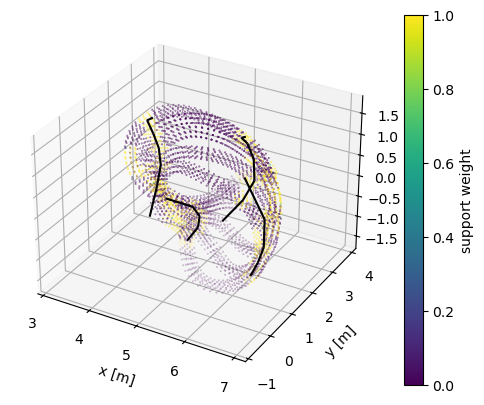

In [5]:
from coil_fem.simsopt import CoilFEMObjective

# The Simsopt wrapper for a differentiable FEM problem.
# It behaves like a simsopt objective.
Jstress = CoilFEMObjective(
    coil_support,
    metrics          = ('l2_von_mises',),
    metric_weights   = (1.,),
    mesh_options     = mesh_options,
    material_options = material_options,
    gravity_options  = gravity_options,
    problem_options  = problem_options,
    physics_options  = physics_options,
    coupling         = 'monolithic',
)
print('# mesh node for all coils:', Jstress.n_nodes)
print('# mesh cell for all coils:', Jstress.n_cells)
# Viusualizing the mesh nodes and support clamps before optimization
Jstress.plot_support()

In [6]:
support   = Jstress.fem.support         # the SupportBeams instance
sdofs     = coil_support.support_dofs      # dict pytree
curves = Jstress.fem.base_curves_jax
# base_dofs = [c.dofs for c in fem.base_curves_jax]
# curves = [CurveXYZFourierJAX(c.quadpoints, base_dofs[i], c.order)
#           for i, c in enumerate(fem.base_curves_jax)]
geom = support._beam_geometry(curves, sdofs)     # note: private, but stable
x_start = np.asarray(geom['x_start'])            # (N_beams, 3)
x_end   = np.asarray(geom['x_end'])              # (N_beams, 3)
gamma3  = np.asarray(support._direction_cosine_matrices(geom, sdofs))  # (N,3,3)

In [7]:
# Pulling beam radii
A_all, Iy, Iz, J = support.cross_section_fn(sdofs)
A = np.concatenate([np.atleast_1d(np.asarray(a)) for a in A_all])  # (N_beams,)
radii = np.sqrt(A / np.pi)          # area-equivalent radius; for solid_circle this == r_beam

In [8]:
import gmsh
gmsh.initialize()
gmsh.model.add("device")
occ = gmsh.model.occ
solids = []
# --- beams: cylinders ---
for xs, xe, r in zip(x_start, x_end, radii):
    d = xe - xs
    tag = occ.addCylinder(xs[0], xs[1], xs[2], d[0], d[1], d[2], float(r))
    solids.append((3, tag))

### Step 2: coil solids
Each coil is lofted from its true FEM cross-section (the $w_1 \times w_2$ rectangle carried on the rotation-minimizing frame), sampled as ring wires along the centerline — the same geometry `coil-fem` sweeps into TET meshes. A closed loop cannot be lofted in one OCC pass, so each coil is two half lofts that the boolean fuse glues back together. Each base coil is then replicated over **every field period and stellarator-symmetry image** (rotate by $2\pi k/n_{fp}$ about $z$, then flip $\mathrm{diag}(1,-1,-1)$ when reflecting — the same convention as `coil_fem.geo.symmetries.apply_symmetries_to_gammas`), reconstructing the complete physical coilset rather than just the pair of images touched by wraparound beams.

In [9]:
# ============================================================================
# Step 2: coils as OCC solids (lofted rectangular sweeps + symmetry images)
# ============================================================================
# Each coil solid is built by lofting its *true* FEM cross-section — the
# w1 x w2 rectangle in the RMF frame, exactly as _rect_sweep_points sweeps it:
#     x = gamma(phi) + (w1/2) u p(phi) + (w2/2) v q(phi)
# OCC cannot loft a closed loop in a single pass, so each coil is built as
# two half lofts; the boolean fuse in Step 3 glues them into one volume.
#
# Every base coil is then replicated over all nfp field periods and (when
# stellsym) the stellarator-reflection image, reconstructing the full
# physical coilset (see the symmetry-image block below).

meshes = Jstress.fem.meshes          # CoilMeshRectangle, one per base coil

def add_coil_solid(mesh, n_slices=96):
    """Loft one coil into two half solids; returns their (dim, tag) list."""
    fc  = mesh.framed_curve
    phi = np.linspace(0.0, 1.0, n_slices, endpoint=False)
    r0  = np.asarray(fc.curve.gamma_eval(phi))       # (K, 3) centerline
    _, p, q = fc.rotated_frame_eval(phi)             # cross-section frame
    p, q = np.asarray(p), np.asarray(q)

    # Same corner convention as the FEM sweep; consistent CCW ordering of the
    # ring wires guarantees the loft does not twist between sections.
    corners = [(-1., -1.), (1., -1.), (1., 1.), (-1., 1.)]
    wires = []
    for k in range(n_slices):
        pts = [
            occ.addPoint(*(r0[k] + 0.5 * mesh.w1 * u * p[k]
                                 + 0.5 * mesh.w2 * v * q[k]))
            for (u, v) in corners
        ]
        lines = [occ.addLine(pts[a], pts[(a + 1) % 4]) for a in range(4)]
        wires.append(occ.addWire(lines))

    # makeRuled=True: straight facets between rings — matches the linear
    # phi-sweep of the FEM mesh and is robust (no B-spline self-intersection).
    half = n_slices // 2
    out  = []
    out += occ.addThruSections(wires[:half + 1], makeSolid=True, makeRuled=True)
    out += occ.addThruSections(wires[half:] + [wires[0]],
                               makeSolid=True, makeRuled=True)
    occ.remove([(1, w) for w in wires], recursive=True)  # construction wires
    return out

coil_solids = [add_coil_solid(m) for m in meshes]


### Step 3: fuse, reflect and mesh
All beam cylinders (including the wraparound/bridge groups) are fused together with the sector's coils into one per-sector unit, which is then rigidly reflected over every field-period rotation and (when stellsym) the stellarator-reflection image. Each master/partner beam pair is designed so its reflected copies land at distinct physical locations — no de-duplication needed.
All beam cylinders, coil half-lofts, and image coils are fused into a single solid — the beam endpoints sit on the coil centerlines, so every cylinder overlaps its coils and the union is watertight and conforming. The fused body is then tet-meshed; mesh size is bounded by the smallest beam radius and the coil width, and `MeshSizeFromCurvature` keeps the cylinder walls round.

In [10]:
# ============================================================================
# Step 3: boolean fuse into one solid + tetrahedral meshing
# ============================================================================
# The beam endpoints lie on the coil *centerlines*, so every cylinder is
# embedded in its two coils and the fuse produces a single conforming volume
# (internal faces — including the half-loft seams — are dissolved).

fused_solid_1fp = solids + [dt for cs in coil_solids for dt in cs]
fused_1fp, _ = occ.fuse(fused_solid_1fp[:1], fused_solid_1fp[1:])
occ.synchronize()

# Reflect the whole per-sector unit (coils + all beams, wraparound/bridge
# groups included) over all nfp field periods and (when stellsym) the
# stellarator-reflection image. Convention mirrors coil_fem.geo.symmetries
# (apply_symmetries_to_gammas): rotate phi = 2*pi*k/nfp about z, then flip
# diag(1, -1, -1) when reflecting; (k=0, flip=False) is fused_1fp itself.
nfp, stellsym = support.nfp, support.stellsym
flip_list = (False, True) if stellsym else (False,)
flip_Q = np.diag([1.0, -1.0, -1.0])

image_solids = []
for k in range(nfp):
    phi = 2.0 * np.pi * k / nfp
    c, s = np.cos(phi), np.sin(phi)
    rot_Q = np.array([[c, -s, 0.0], [s, c, 0.0], [0.0, 0.0, 1.0]])
    for flip in flip_list:
        if k == 0 and not flip:
            continue  # identity: already in fused_1fp
        Q = (flip_Q @ rot_Q) if flip else rot_Q   # rotate, then flip
        affine = list(np.hstack([Q, np.zeros((3, 1))]).ravel())
        copies = occ.copy(fused_1fp)
        occ.affineTransform(copies, affine)
        image_solids += copies

n_images = nfp * len(flip_list) - 1
print(f'{len(solids)} beam cylinders, '
      f'{sum(len(c) for c in coil_solids)} base-coil half-lofts, '
      f'{len(image_solids)} image half-lofts '
      f'({n_images} field-period/symmetry images x {len(coil_solids)} base coils)')


20 beam cylinders, 10 base-coil half-lofts, 9 image half-lofts (9 field-period/symmetry images x 5 base coils)


In [11]:
# fused_1fp is itself a list of (dim, tag) pairs (occ.fuse's output), so it
# must be *concatenated* with the other lists, not nested inside another list
# (nesting is what produced the "Invalid data for input vector of pairs"
# error -- gmsh expects one flat list of (dim, tag) tuples).
fused_solid_all = fused_1fp + image_solids
fused_all, _ = occ.fuse(fused_solid_all[:1], fused_solid_all[1:])
occ.synchronize()

Info    : [ 90%] Union - Making faces                                                                                

In [12]:

vols = gmsh.model.getEntities(3)
print(f'{len(vols)} volume(s) after fuse')   # >1 means a part is not touching
gmsh.model.addPhysicalGroup(3, [t for _, t in vols], name='device')

# Mesh sizing: resolve the beam radii and the coil cross-section.
r_min = float(radii.min())
gmsh.option.setNumber('Mesh.MeshSizeMax', 0.5 * mesh_options['w1'])
gmsh.option.setNumber('Mesh.MeshSizeMin', 0.15 * r_min)
gmsh.option.setNumber('Mesh.MeshSizeFromCurvature', 12)  # pts per 2*pi
# gmsh.option.setNumber('Mesh.ElementOrder', 2)  # uncomment for TET10

t0 = time.time()
gmsh.model.mesh.generate(3)
print(f'meshed in {time.time() - t0:.1f} s')


1 volume(s) after fuse
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (BSpline)
Info    : [ 10%] Meshing curve 2 (BSpline)
Info    : [ 10%] Meshing curve 3 (BSpline)
Info    : [ 10%] Meshing curve 4 (BSpline)
Info    : [ 10%] Meshing curve 5 (BSpline)
Info    : [ 10%] Meshing curve 6 (BSpline)
Info    : [ 10%] Meshing curve 7 (BSpline)
Info    : [ 10%] Meshing curve 8 (Line)
Info    : [ 10%] Meshing curve 9 (BSpline)
Info    : [ 10%] Meshing curve 10 (BSpline)
Info    : [ 10%] Meshing curve 11 (BSpline)
Info    : [ 10%] Meshing curve 12 (Circle)
Info    : [ 10%] Meshing curve 13 (BSpline)
Info    : [ 10%] Meshing curve 14 (BSpline)
Info    : [ 10%] Meshing curve 15 (Circle)
Info    : [ 10%] Meshing curve 16 (BSpline)
Info    : [ 10%] Meshing curve 17 (BSpline)
Info    : [ 10%] Meshing curve 18 (BSpline)
Info    : [ 10%] Meshing curve 19 (BSpline)
Info    : [ 10%] Meshing curve 20 (BSpline)
Info    : [ 10%] Meshing curve 21 (BSpline)
Info    : [ 10%] Meshing curve 22 (BSpline)

Info    : Done optimizing mesh (Wall 1.08469s, CPU 1.08436s)
Info    : 169299 nodes 930733 elements


meshed in 35.2 s
Info    : Writing 'device.msh'...
Info    : Done writing 'device.msh'


In [15]:
gmsh.write('full_mesh.msh')  # portable fallback for a separate dolfinx env
gmsh.write('full_mesh.vtk')

Error   : Gmsh has not been initialized
Error   : Gmsh has not been initialized


Exception: Could not get last error

### Step 4: import into dolfinx
`dolfinx.io.gmshio.model_to_mesh` converts the live gmsh model directly (the physical group added in Step 3 is required — dolfinx only imports tagged cells). If dolfinx is installed in a different environment than gmsh/coil-fem, use `gmshio.read_from_msh('device.msh', ...)` there instead.

In [13]:
# ============================================================================
# Step 4: import into dolfinx
# ============================================================================
# Reads the mesh straight from the live gmsh model (no file round-trip).
# If dolfinx lives in a different environment, run there instead:
#     domain, ct, ft = gmshio.read_from_msh('device.msh', MPI.COMM_WORLD,
#                                           rank=0, gdim=3)
from mpi4py import MPI
from dolfinx.io import gmshio

domain, cell_tags, facet_tags = gmshio.model_to_mesh(
    gmsh.model, MPI.COMM_WORLD, rank=0, gdim=3,
)
gmsh.finalize()

tdim = domain.topology.dim
domain.topology.create_connectivity(tdim, tdim)
print('cells:', domain.topology.index_map(tdim).size_global)
print('nodes:', domain.geometry.x.shape[0])

cells: 545450
nodes: 169299
